# Importing utils

In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer,KNNImputer
from  sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

In [30]:
df = pd.read_csv('train_backpack.csv')

In [31]:
df.head()

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312


In [32]:
df.isna().sum()

id                         0
Brand                   9705
Material                8347
Size                    6595
Compartments               0
Laptop Compartment      7444
Waterproof              7050
Style                   7970
Color                   9950
Weight Capacity (kg)     138
Price                      0
dtype: int64

### OverView of the Data 

In [33]:
# from ydata_profiling import ProfileReport
# prof = ProfileReport(df)
# prof.to_file(output_file='output.html')

## Exploratory Data Extraction

In [34]:
df.drop(columns=['id'],inplace=True)

In [35]:
(df['Brand'].value_counts()*100)/len(df)

Brand
Adidas          20.025667
Under Armour    19.997333
Nike            19.112000
Puma            18.938000
Jansport        18.692000
Name: count, dtype: float64

### I Have Seen Every Compartment where it have categorical value every on is fine only few percentage of missing values , we going to use Simple Imputer for filling those data , 
### Every category frequency has not any high trip also

<Axes: >

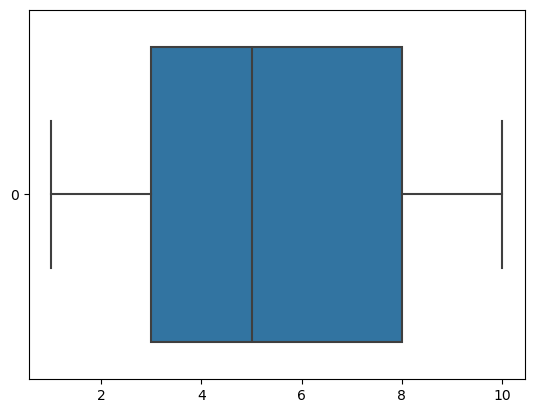

In [36]:
sns.boxplot(df['Compartments'],orient='h')

<Axes: >

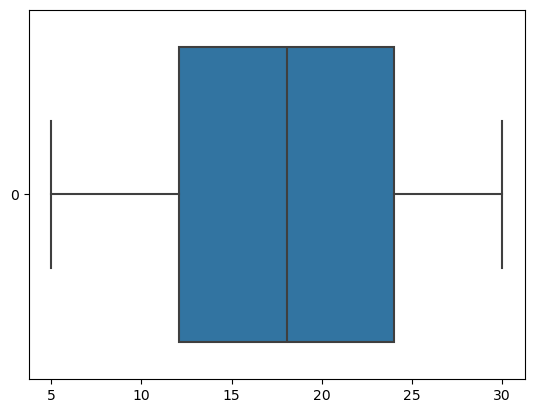

In [37]:
sns.boxplot(df['Weight Capacity (kg)'],orient='h')

<Axes: >

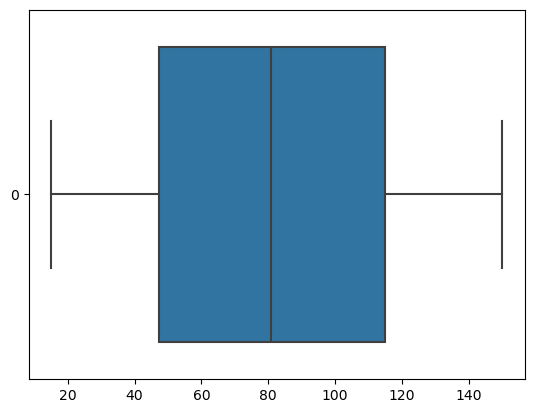

In [38]:
sns.boxplot(df['Price'],orient='h')

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


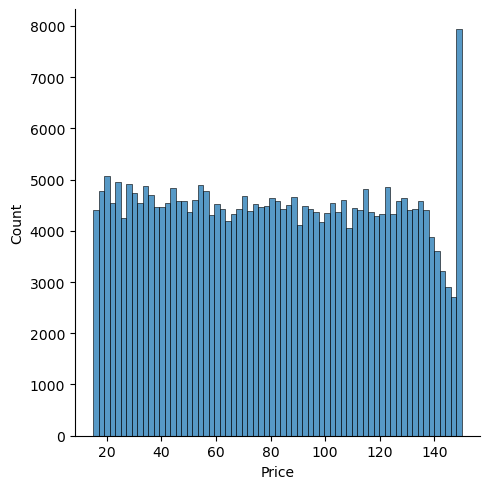

In [39]:
sns.displot(df['Price'])

In [40]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Feature Enginnering and Model Formation

### Imputer Transformer

In [42]:
trf1 = ColumnTransformer([
    ('impute',KNNImputer(),[3,8]),
    ('impute2',SimpleImputer(strategy='most_frequent'),[0,1,2,4,5,6,7])
],remainder='passthrough')

### One hot encoding

In [43]:
trf2 = ColumnTransformer([
    ('ordinal encoding', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), [0,1,2,4,5,6,7])
], remainder='passthrough')

array([[ 2.        ,  1.        ,  1.        , ...,  2.        ,
         1.        , 27.29487961],
       [ 3.        ,         nan,  0.        , ...,  1.        ,
         9.        ,  8.57454498],
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         8.        , 11.50243568],
       ...,
       [ 3.        ,  3.        ,  0.        , ...,  0.        ,
        10.        , 14.79469275],
       [ 0.        ,  2.        ,  0.        , ...,  1.        ,
         5.        , 21.06767483],
       [ 0.        ,  2.        ,  2.        , ...,  2.        ,
         8.        , 13.73519908]])

### Model

In [44]:
trf3 = LinearRegression()

### Mixed the pipe lines

In [45]:
pipe = Pipeline([
    ('trf1',trf1),
    ('trf2',trf2),
    ('trf3',trf3)
])

In [52]:
trf1 = ColumnTransformer([
    ('impute', KNNImputer(), [3,8]),
    ('impute2', SimpleImputer(strategy='most_frequent'), [0,1,2,4,5,6,7])
], remainder='passthrough')

# Then encode ALL categorical columns
trf2 = ColumnTransformer([
    ('ordinal encoding', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), 
     [0,1,2,4,5,6,7])
], remainder='passthrough')

# Make sure there are no string columns left before the regression step
pipe = Pipeline([
    ('trf1', trf1),
    ('trf2', trf2),
    ('trf3', DecisionTreeRegressor())
])

pipe.fit(X_train, y_train)

ValueError: could not convert string to float: 'Leather'

In [ ]:
y_pred = pipe.predict(X_test)

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(pipe,X_train,y_train,cv=5,scoring='mse').mean()

In [ ]:
len(df)

300000